# Intertidal topography of the Ría de Villaviciosa

**A complete worked study with `pyintertidal`** — from raw Sentinel-2 imagery
to an elevation model, its ecological interpretation and an independent
validation.

This notebook is also the reference example of the library. Every step is an
explicit function call with its parameters written out in variables, and after
each operation a diagram shows what happened to the datacube. Nothing is
hidden behind a "run everything" call: if you can read this notebook, you know
exactly how the result was produced.

**Study site.** The Ría de Villaviciosa (Asturias, N Spain) is a mesotidal
estuary with sandy flats, a meandering main channel and salt marsh in its
upper reaches. It is our reference site: an IGN LiDAR survey covers it, and we
have a field transect at Misiego.

**What we produce**

| Product | What it answers |
|---|---|
| Reference map | where the coast is stable and where it is transitional |
| Water frequency | how often each pixel is wet |
| Intertidal mask | where the intertidal zone is, and how large |
| Elevation + uncertainty | how high each pixel stands, and how sure we are |
| Sub-pixel relief | where there is structure finer than 10 m |
| Hydroperiod & zonation | how long each pixel is submerged → habitat |
| Hypsometry | the morphological signature of the estuary |
| Validation | how it compares with airborne LiDAR |


## Parameters

Everything that changes between one run and another lives in the next cell,
and nothing else in the notebook is site-specific. That is what lets the same
file be both the worked study of Villaviciosa and the production cell of a
regional campaign: the orchestrator replaces this one cell and executes the
rest untouched, so every cell that runs over the north coast is a cell you can
read here.

Section-level parameters — thresholds, epoch length, the fitting grid — stay
where they are used, further down. They are choices about the *method*, not
about *which* area is being mapped, and hoisting them here would hide them.


In [1]:
# ── Which area, and over what period ────────────────────────────────────
SITE         = "villaviciosa"   # registry key; ignored when POLYGON is given
POLYGON      = None             # [(lon, lat), …] — a campaign cell sets this
RUN_NAME     = None             # names the cache, products and report

TIME_EXTENT  = ("2016-01-01", "2025-12-31")
TIDE_MODEL   = None             # None → the model the site declares (EOT20)

# ── Campaign behaviour (both False for an interactive study) ────────────
EVICT_CUBE   = False            # delete the cube once products are verified
STRICT       = False            # raise instead of skipping an empty cell

# ── Site-specific validation: only Villaviciosa has these ───────────────
# A campaign cell leaves them None and the validation sections skip
# themselves. Skipping is reported, never silent — a section that vanishes
# without saying so is how a notebook starts lying about what it checked.
MDT_PATH     = "mdt5_villaviciosa_grande.tif"   # IGN LiDAR, if it covers the area
FIELD_CSV    = "data/villaviciosa_rtk_gnss.csv"  # RTK GNSS survey

# ── Derived, so the rest of the notebook never repeats the logic ────────
RUN_NAME = RUN_NAME or (SITE if POLYGON is None else "cell")

# Villaviciosa's cube was downloaded before this notebook was parameterised,
# under a name that does not follow the rule below, and over a slightly wider
# box (915x915 rather than 887x673). Every product, figure and validation in
# this project sits on THAT grid. Deriving the cache name from RUN_NAME alone
# silently downloaded a second 2.2 GB cube on a different grid and wrote
# products from both into one directory — mixed grids that misalign without
# raising anything. Pin the known cubes by name.
KNOWN_CACHES = {"villaviciosa": "ndwi_cube_villaviciosa_grande_10y.nc"}
CACHE    = KNOWN_CACHES.get(RUN_NAME, f"ndwi_cube_{RUN_NAME}.nc")
OUT_DIR  = f"products_{RUN_NAME}"

print(f"run {RUN_NAME!r} · {TIME_EXTENT[0]} → {TIME_EXTENT[1]}")
print(f"  cache   {CACHE}")
print(f"  outputs {OUT_DIR}")


run 'villaviciosa' · 2016-01-01 → 2025-12-31
  cache   ndwi_cube_villaviciosa.nc
  outputs products_villaviciosa


## 0 · Setup

One import for the library, one connection to Copernicus. The connection is only used if the datacube is not already cached on disk.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyintertidal as pit
from pyintertidal import SentinelCube, TideService, explain, viz


print("pyintertidal", pit.__version__)

# `connect` also fixes SSL certificate handling on Windows before
# authenticating with OpenID Connect (a browser opens the first time).
conn = pit.scenes.connect()

pyintertidal 0.1.0


## 1 · Study area

The area of interest is a **polygon**, not a bounding box. The bounding box is
used internally to download a (rectangular) datacube, but every product and
every figure is clipped back to the polygon — which is what lets contiguous
tiles of a regional campaign fit together without overlaps.

The site comes from the registry so the same coordinates are used by this
notebook, the validation and the field campaign.

In [3]:
aoi = (pit.sites.get(SITE) if POLYGON is None
       else pit.AOI.from_polygon(POLYGON, name=RUN_NAME))

print(aoi)
print(f"  bounding box used for the download: "
      f"{ {k: round(v, 3) for k, v in aoi.bbox.items()} }")
print(f"  polygon centroid: {aoi.centroid[0]:.4f}, {aoi.centroid[1]:.4f}")

# How this AOI would be split for a regional campaign. When POLYGON is set we
# ARE one of those cells already, so there is nothing to split.
tiles = aoi.tile(cell_km=5) if POLYGON is None else []
if tiles:
    print(f"  as production tiles of 5 km: {len(tiles)} cells covering "
          f"{sum(t.area_km2 for t in tiles):.1f} km²")


AOI('Villaviciosa', 44.4 km², [-5.455, 43.470, -5.375, 43.548])
  bounding box used for the download: {'west': -5.455, 'south': 43.47, 'east': -5.375, 'north': 43.548}
  polygon centroid: 43.5090, -5.4161
  as production tiles of 5 km: 4 cells covering 44.4 km²


(<Figure size 1500x1200 with 1 Axes>,
 <Axes: title={'center': 'Area of interest — Villaviciosa (44.4 km²)'}>)

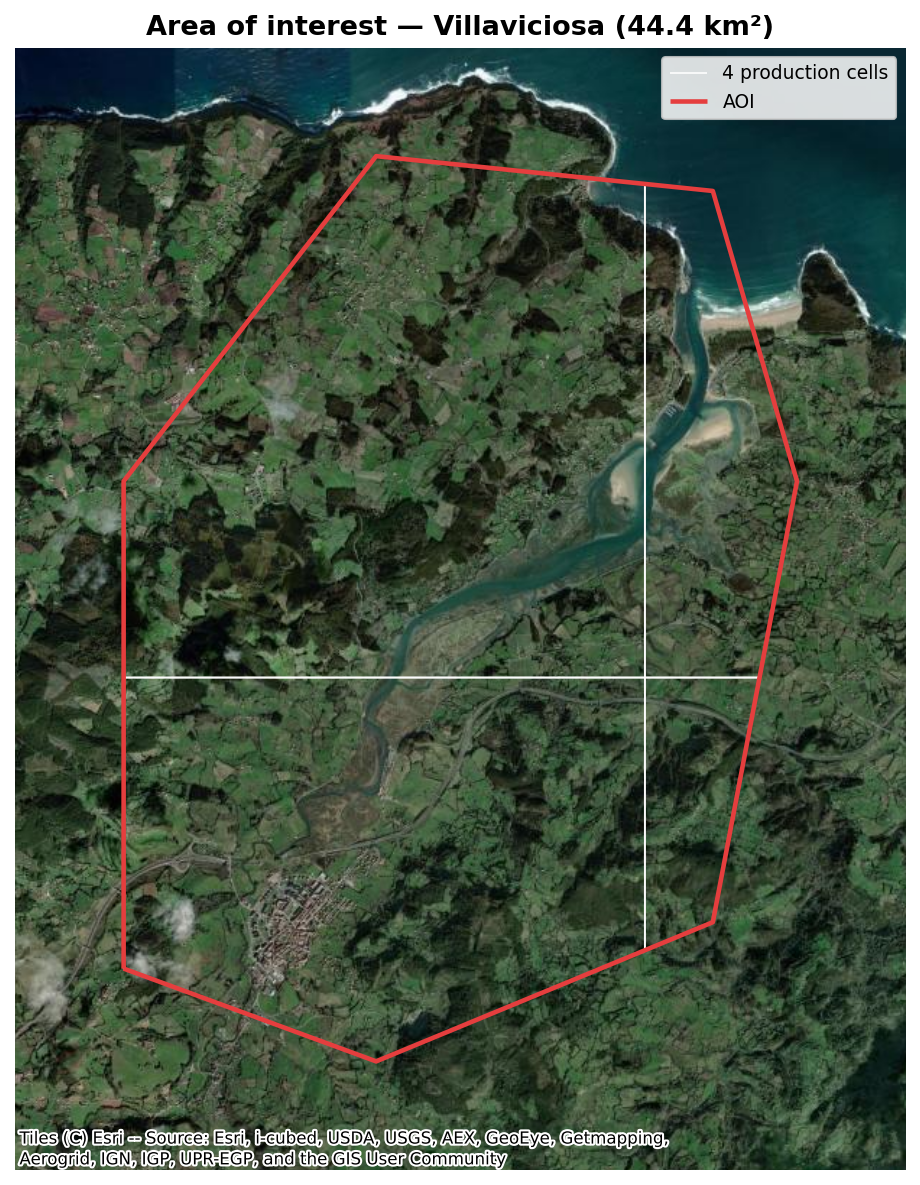

In [4]:
# Where the study area actually is. Over satellite imagery, because the first
# question about any AOI is whether it covers the estuary you meant and stops
# where you meant it to. The outline is the POLYGON, never the bounding box.
# `tiles=` overlays the production cells so the regional split can be checked
# before launching one notebook per cell.
viz.plot_aoi(aoi, tiles=tiles)

## 2 · The datacube

All the imagery this study needs is downloaded **once** and cached as a
netCDF cube. Every later step streams that file in small time blocks, so
memory stays bounded no matter how long the archive is — a decade of imagery
over 80 km² would be ≈ 8 GB if loaded whole, and we never load it whole.

The bands come from the water detector: NDWI needs B03 and B08 (both native
10 m, which is why NDWI has true 10 m resolution), plus SCL for the cloud
mask.

In [5]:
# ── Parameters ──────────────────────────────────────────────────────────
# TIME_EXTENT and CACHE come from the parameters cell at the top; these two
# are properties of the method, not of the area, so they stay here.
WATER         = "ndwi"                          # ndwi | mndwi | awei | scl
RESOLUTION_M  = 10                              # native for B03/B08

# ── Acquisition ─────────────────────────────────────────────────────────
cube = SentinelCube(aoi, TIME_EXTENT, water=WATER,
                    cache_path=CACHE, resolution=RESOLUTION_M)
cube.ensure(conn)          # downloads only if the cache does not exist

transform, crs = cube.grid
print(f"{len(cube.dates)} scenes · grid {cube.shape[0]}×{cube.shape[1]} "
      f"@ {abs(transform.a):g} m · {crs}")
print(f"first {cube.dates[0]} · last {cube.dates[-1]}")


[cube] using cache ndwi_cube_villaviciosa.nc


1379 scenes · grid 887×673 @ 10 m · EPSG:32630
first 2016-01-01 · last 2025-12-29


In [6]:
# What the archive actually offers here. The revisit statistics matter more
# than the raw count: a decade with one long gap is not the same archive as a
# decade sampled evenly, and those gaps are what later decide which epochs can
# be fitted at all. Open "Every date" for the full listing.
explain.dates_available(cube.dates, TIME_EXTENT)

<pyintertidal summary — display it in a notebook>

What is actually inside that cube — bands as rows, time as columns, filled with real (heavily downsampled) imagery so the clouds and tide states are visible:

In [7]:
explain.describe_cube(cube, with_data=True, max_columns=6)

<pyintertidal diagram: Villaviciosa · 2016-01-01 → 2025-12-31 · water=ndwi — display it in a notebook or call .save(path)>

In [8]:
explain.summarize(cube)

,Array,Chunk
Bytes,4.60 GiB,128.00 KiB
Shape,"(3, 1,379, 887, 673)","(3, 1, 256, 256)"
Chunks,"49,644 on disk",1×256×256
Streaming,112.72 MiB in RAM,33 dates/pass
Data type,int16 numpy.ndarray,
band,(band) <U3,'B03' 'B08' 'SCL'
t,(time) datetime64,2016-01-01 2016-01-11 2016-01-18 ... 2025-12-26 2025-12-28 2025-12-29
y,(y) float64,"4,824,610 … 4,815,740"
x,(x) float64,"301,420 … 308,150"
crs,,EPSG:32630


We record the rest of the analysis so that, at the end, the notebook can
draw the process graph that produced every number in it.

In [9]:
log = explain.OpLog("Villaviciosa 2016–2025")
log.record("acquire datacube", kind="acquire",
           params={"water": WATER, "resolution_m": RESOLUTION_M},
           outputs=["cube"],
           note=f"{len(cube.dates)} scenes, cached once")

Operation(name='acquire datacube', kind='acquire', params={'water': 'ndwi', 'resolution_m': 10}, inputs=[], outputs=['cube'], before=None, after=None, note='1379 scenes, cached once', seconds=0.0)

## 3 · Water detection threshold

NDWI separates water from land, but the optimal cut is site-dependent:
turbid estuarine water sits lower than the textbook 0.0. Rather than guessing,
we let the data decide with Otsu's method over the clearest scenes, and then
look at the number before adopting it.

In [10]:
# ── Calibration: let the data suggest the threshold ─────────────────────
# `calibrate_threshold` ranks the archive by cloudiness, pools the clear-sky
# NDWI of the clearest scenes and returns Otsu's split of that sample. A
# result pinned at the ends of the allowed range is a warning, not an answer.
otsu, info = pit.water.calibrate_threshold(cube, n_scenes=12)

# ── Parameter (adopted explicitly, informed by the calibration) ──────────
NDWI_THRESHOLD = 0.0     # turbid estuarine water sits below the textbook 0.1
print()
print(f"adopted NDWI threshold: {NDWI_THRESHOLD:+.3f}  "
      f"(a pixel counts as water when NDWI exceeds this)")

[water] Otsu on 418,251 clear pixels from 12 scenes → -0.400  (clipped — the sample was not clearly bimodal; set the threshold manually)

adopted NDWI threshold: +0.000  (a pixel counts as water when NDWI exceeds this)


## 4 · Coastal stability and cloud screening

Two products from two streaming passes:

1. **Reference map** — each pixel voted wet/dry across the CLEAN scenes and
   labelled stable water, stable land or *transition*. The transition class is
   the intertidal candidate zone.
2. **Per-date cloudiness** — measured globally for clear scenes and, for
   cloudy ones, **inside the transition zone only**. That distinction is what
   rescues dates: a scene can be 80 % cloudy overall and perfectly clear over
   the estuary.

In [11]:
# ── Parameters ──────────────────────────────────────────────────────────
CLEAN_SCENE_MAX_BAD  = 0.05   # a scene votes in the reference map if <5% cloud
STABLE_THRESHOLD     = 0.95   # 95% of votes agree → stable water/land
TRANSITION_BUFFER_PX = 10     # safety halo around the transition zone
BAD_CLASSES          = pit.water.BAD_CLASSES     # SCL cloud/shadow classes

# ── Reference map + per-date cloudiness ─────────────────────────────────
reference_map, cloud_pct = pit.reference_and_clouds(
    cube,
    threshold=NDWI_THRESHOLD,
    bad_classes=BAD_CLASSES,
    clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
    stable_threshold=STABLE_THRESHOLD,
    transition_buffer_px=TRANSITION_BUFFER_PX,
)

px_km2 = abs(transform.a * transform.e) / 1e6
for code, name in [(0, "transition"), (1, "stable water"), (2, "stable land")]:
    n = int((reference_map == code).sum())
    print(f"  class {code} ({name:13s}): {n:>8,} px  {n * px_km2:6.2f} km²")

log.record("reference map + cloud stats", kind="reduce",
           params={"stable_threshold": STABLE_THRESHOLD,
                   "buffer_px": TRANSITION_BUFFER_PX},
           inputs=["cube"], outputs=["reference map", "cloud %"])

  class 0 (transition   ):   75,848 px    7.58 km²
  class 1 (stable water ):   15,056 px    1.51 km²
  class 2 (stable land  ):  506,047 px   50.60 km²


Operation(name='reference map + cloud stats', kind='reduce', params={'stable_threshold': 0.95, 'buffer_px': 10}, inputs=['cube'], outputs=['reference map', 'cloud %'], before=None, after=None, note='', seconds=0.0)

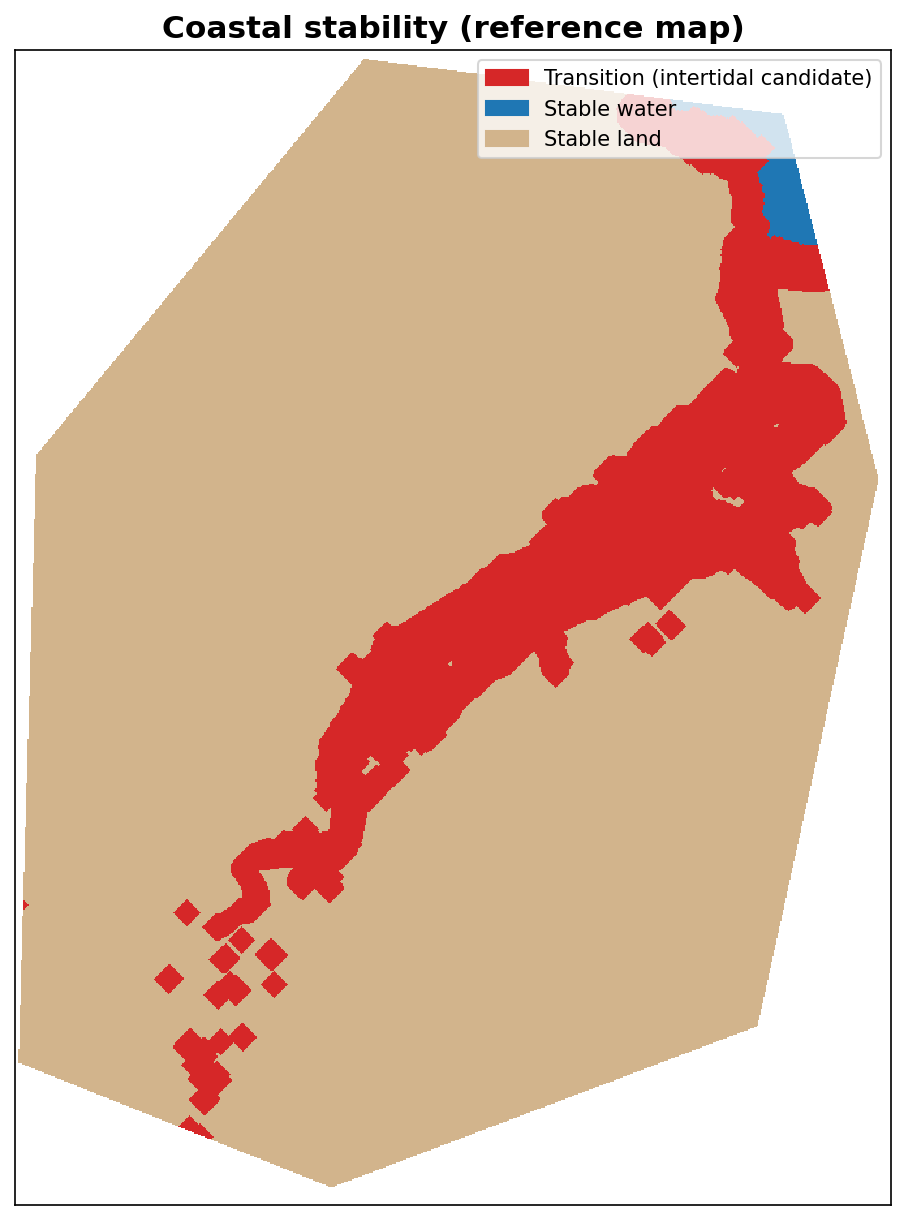

In [12]:
viz.plot_reference_map(reference_map, transform, crs, aoi);

Now the date filter. We keep the dates that are clear **over the transition zone**, and measure how many that rescues compared with a whole-scene filter:

In [13]:
# ── Parameter ───────────────────────────────────────────────────────────
CLOUD_THRESHOLD = 0.10        # ≤10% cloud over the transition zone

usable_dates = pit.filter_dates(cloud_pct, cloud_threshold=CLOUD_THRESHOLD)
gain = pit.date_recovery_gain(cloud_pct,
                              clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
                              cloud_threshold=CLOUD_THRESHOLD)

log.record("filter dates", kind="filter",
           params={"cloud_threshold": CLOUD_THRESHOLD},
           outputs=[f"{len(usable_dates)} dates"],
           note=f"+{gain['gain_relative_pct']:.0f}% vs a global filter")

[dates] 1379 acquisitions → 291 clear scenes (21%) → 310 usable after the transition-zone filter (22%)
        19 dates recovered (+7% more observations)


Operation(name='filter dates', kind='filter', params={'cloud_threshold': 0.1}, inputs=[], outputs=['310 dates'], before=None, after=None, note='+7% vs a global filter', seconds=0.0)

In [14]:
# Which dates survived and, more to the point, WHY. Three outcomes:
#   [ref]  clean over the whole scene, so it votes in the reference map
#   [✓]    too cloudy globally but clear over the transition zone — an
#          observation a whole-scene filter would have thrown away
#   [✗]    cloudy where it matters
explain.cloud_screening(cloud_pct, usable_dates,
                        clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
                        cloud_threshold=CLOUD_THRESHOLD)

[ref],2016-01-01,0.0 %
[ref],2016-01-11,4.5 %
[✗],2016-01-18,10000.0 %
[✗],2016-01-21,10000.0 %
[✗],2016-02-10,10000.0 %
[✗],2016-02-17,10000.0 %
[✗],2016-03-11,9250.7 %
[✓],2016-03-18,281.0 %
[✗],2016-03-21,10000.0 %
[✗],2016-03-28,10000.0 %
[✗],2016-04-07,10000.0 %


What that filter did to the cube — same dimensions, fewer labels:

In [15]:
explain.draw_operation(
    "filter dates · clouds ≤ 10% over the transition zone",
    kind="filter",
    before={"bands": cube.bands, "n_dates": len(cube.dates), "shape": cube.shape},
    after={"bands": cube.bands, "n_dates": len(usable_dates), "shape": cube.shape},
    note=f"{len(cube.dates):,} → {len(usable_dates):,} dates",
    params={"cloud_threshold": CLOUD_THRESHOLD})

<pyintertidal diagram: filter dates · clouds ≤ 10% over the transition zone — display it in a notebook or call .save(path)>

## 5 · Water frequency and the intertidal zone

Water frequency is the fraction of clear observations in which each pixel was
wet. Stable water sits near 1, stable land near 0, and the intertidal zone
spans the middle — ordered by elevation, because higher flats flood less
often.

`min_obs` guards against pixels with too little evidence: a pixel seen twice
can report a frequency of 1.0 and mean nothing.

In [16]:
# ── Parameters ──────────────────────────────────────────────────────────
MIN_OBS = max(8, round(0.05 * len(usable_dates)))   # ≥8, or 5% of the archive
print(f"a pixel needs at least {MIN_OBS} clear observations")

# ── Water frequency (streamed over the usable dates) ────────────────────
water_freq = pit.water_frequency(
    cube, dates=usable_dates, threshold=NDWI_THRESHOLD, min_obs=MIN_OBS)

valid = np.isfinite(water_freq)
print(f"water frequency computed for {valid.sum():,} px "
      f"({100 * valid.mean():.1f}% of the grid)")

log.record("water frequency", kind="reduce",
           params={"min_obs": MIN_OBS, "threshold": NDWI_THRESHOLD},
           inputs=[f"{len(usable_dates)} dates"], outputs=["water frequency"])

a pixel needs at least 16 clear observations


water frequency computed for 596,951 px (100.0% of the grid)


Operation(name='water frequency', kind='reduce', params={'min_obs': 16, 'threshold': 0.0}, inputs=['310 dates'], outputs=['water frequency'], before=None, after=None, note='', seconds=0.0)

In [17]:
# The product itself: shape, grid, valid pixels and range, on the same panel
# the cube gets. `Valid` is the number to read first — a map can look complete
# and still be mostly NaN.
explain.summarize(water_freq, name="water frequency", transform=transform,
                  crs=crs, long_name="Fraction of clear observations wet")

,Array,Chunk
Bytes,2.28 MiB,
Shape,"(887, 673)",
Valid,"596,951 px (100.0 %)",
Range,0.000 … 1.000,
Data type,float32 numpy.ndarray,
long_name,,Fraction of clear observations wet
resolution,,10 m
extent,,6.73 × 8.87 km
valid_area,,59.70 km²
crs,,EPSG:32630


The time dimension has collapsed: hundreds of dates became one map.

In [18]:
explain.draw_operation(
    "water frequency · fraction of clear observations wet",
    kind="reduce",
    before={"bands": cube.bands, "n_dates": len(usable_dates), "shape": cube.shape},
    after={"bands": ["water frequency"], "n_dates": 1, "shape": cube.shape},
    note=f"{len(usable_dates)} dates → 1 map",
    params={"min_obs": MIN_OBS})

<pyintertidal diagram: water frequency · fraction of clear observations wet — display it in a notebook or call .save(path)>

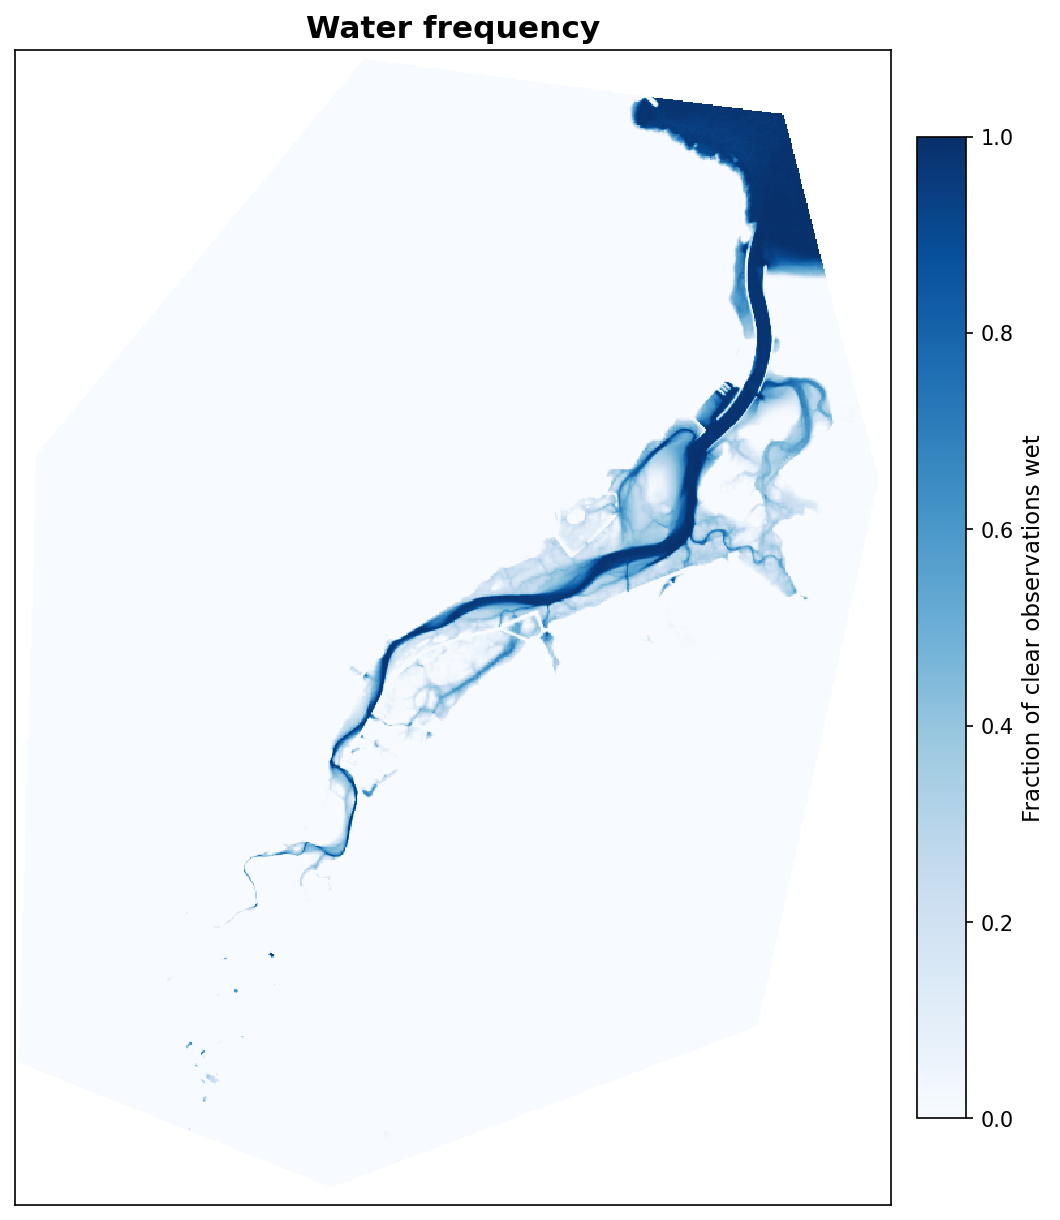

In [19]:
viz.plot_water_frequency(water_freq, transform, crs, aoi);

The intertidal zone is the transition class with a water frequency between
two bounds. The bounds can be pinned by hand, or found from the data: inside
the transition zone the histogram mixes three populations (almost never wet,
truly intertidal, almost always wet) and a 3-class Otsu split finds the two
valleys between them.

In [20]:
# ── Parameters ──────────────────────────────────────────────────────────
transition = reference_map == 0
otsu_low, otsu_high = pit.multiotsu_window(water_freq, transition)
print(f"multi-Otsu suggests the intertidal window "
      f"[{otsu_low:.2f}, {otsu_high:.2f}]")

# Adopted wider than the suggestion, on purpose. Multi-Otsu splits the
# transition histogram into three populations and hands back the two valleys,
# which cuts off the ends of the flat: the lowest ground, wet on almost every
# pass, and the highest, dry on almost every pass. Those ends are real
# intertidal and the fit can resolve them, so the window is opened and the
# per-pixel quality control is left to decide instead.
WF_LOW, WF_HIGH = 0.05, 0.95

# ── Intertidal mask (also clipped to the study polygon) ─────────────────
polygon_mask   = aoi.raster_mask(transform, crs, reference_map.shape)
intertidal     = pit.intertidal_mask(water_freq, reference_map,
                                     WF_LOW, WF_HIGH, aoi_mask=polygon_mask)

area_km2 = intertidal.sum() * px_km2
narrow = pit.intertidal_mask(water_freq, reference_map, otsu_low, otsu_high,
                             aoi_mask=polygon_mask)
print(f"intertidal zone: {int(intertidal.sum()):,} px = {area_km2:.2f} km² "
      f"(the multi-Otsu window would give {int(narrow.sum()):,} px = "
      f"{narrow.sum() * px_km2:.2f} km²)")

log.record("intertidal mask", kind="mask",
           params={"wf_low": WF_LOW, "wf_high": WF_HIGH},
           outputs=["intertidal mask"], note=f"{area_km2:.2f} km²")

multi-Otsu suggests the intertidal window [0.21, 0.65]
intertidal zone: 30,446 px = 3.04 km² (the multi-Otsu window would give 17,662 px = 1.77 km²)


Operation(name='intertidal mask', kind='mask', params={'wf_low': 0.05, 'wf_high': 0.95}, inputs=[], outputs=['intertidal mask'], before=None, after=None, note='3.04 km²', seconds=0.0)

In [21]:
# Where every pixel of the candidate zone ended up. The transition class is
# only a CANDIDATE; the water-frequency window then splits it into ground
# almost never wet, ground almost always wet, and the intertidal proper.
# Reporting the three together is what makes the window a defensible choice
# instead of a magic number — widen it and you see exactly what you gained.
explain.intertidal_breakdown(reference_map, water_freq, intertidal,
                             WF_LOW, WF_HIGH, transform)

,intertidal,"30,446 px",3.04 km²,40.1 %
,terrestrial,"33,676 px",3.37 km²,44.4 %
,aquatic,"10,219 px",1.02 km²,13.5 %


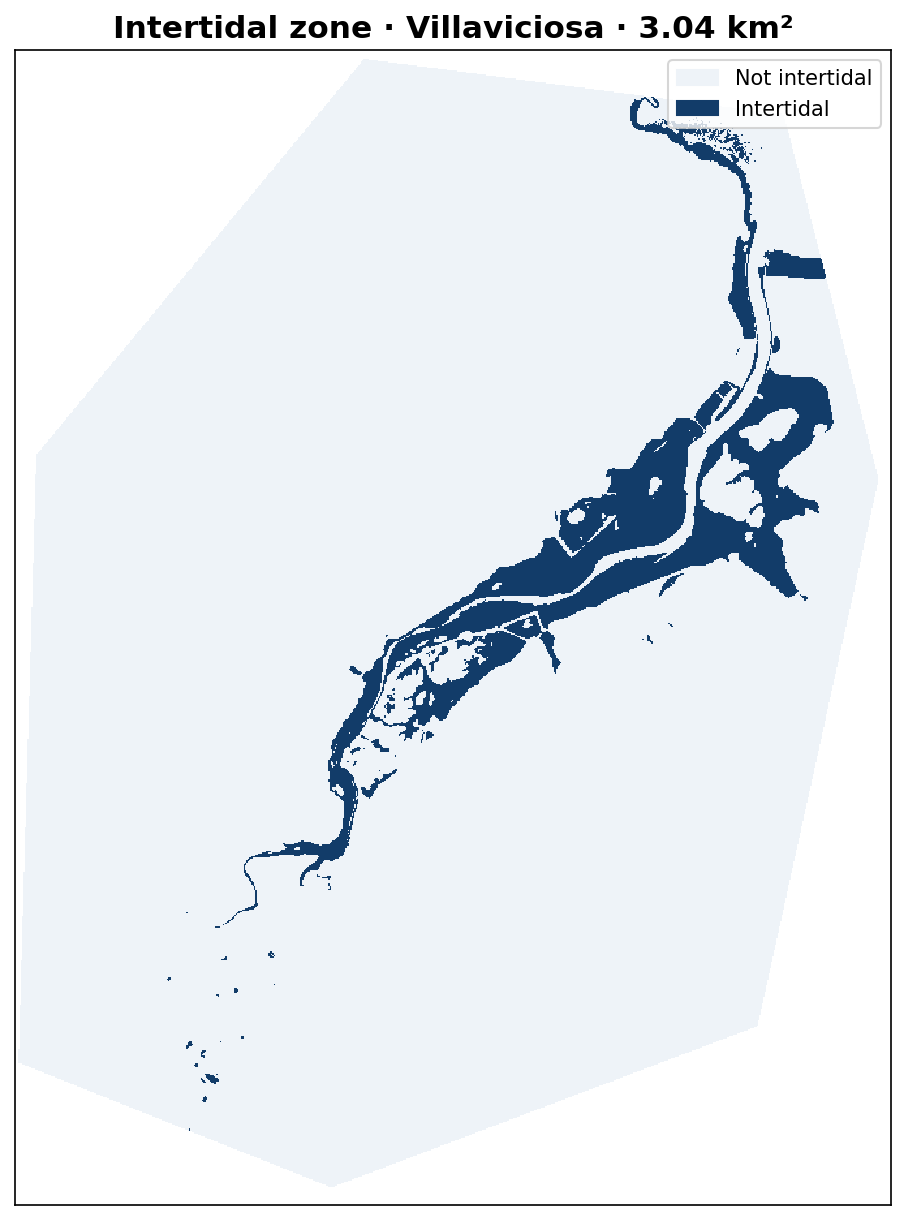

In [22]:
viz.plot_intertidal(intertidal, transform, crs, aoi,
                    title=f"Intertidal zone · {aoi.name} · {area_km2:.2f} km²");

## 6 · Tides

Elevation methods need the water level at the moment each image was taken, so
we pair every usable date with its real acquisition time (from the Copernicus
catalogue) and predict the tide there with a global harmonic model.

Two refinements worth noting. The prediction point defaults to the polygon
centroid, which in a curved estuary can fall on land where the model returns
nothing; `water_centroid` instead picks the middle of the main channel. And
the continuous series (not the satellite dates) is what later drives the
sampling diagnostics and the hydroperiod.

In [23]:
# ── Parameters ──────────────────────────────────────────────────────────
TIDE_MODEL = TIDE_MODEL or (pit.sites.tide_model(SITE) if POLYGON is None
                            else "EOT20")
TIDE_DIR   = "./tide_models"

tide_point = pit.water_centroid(reference_map, transform, crs)
print(f"tide prediction point (mid-channel): "
      f"{tide_point[0]:.4f}, {tide_point[1]:.4f}")

# How far away is the nearest cell where this model predicts anything at all?
# Tide models are defined on an ocean grid and an estuary usually falls on a
# LAND cell, so every implementation searches outward until it finds water —
# silently. Here that search reaches 34 km with GOT4.10 and 13 km with EOT20,
# which is a term in the error budget and belongs in the record.
ocean = pit.tidecheck.nearest_ocean_km(*tide_point, model=TIDE_MODEL,
                                       directory=TIDE_DIR)

tides = TideService(model=TIDE_MODEL, directory=TIDE_DIR, location=tide_point)

# Tide height at each satellite acquisition …
tide_heights = tides.heights_for(aoi, usable_dates)

# … and the continuous series that represents the real tidal regime.
# The full study period, not one year: the tidal frame is a decadal
# quantity. The 18.6-year nodal cycle plus the annual and semiannual terms
# all move the extremes, so a single year understates the frame our
# elevations are referenced to. About a minute of pyTMD for ten years.
series_times, series_heights = tides.series(aoi, TIME_EXTENT[0],
                                            TIME_EXTENT[1], every_hours=1)
print(f"reference series: {len(series_times):,} hourly predictions, "
      f"range [{np.nanmin(series_heights):+.2f}, "
      f"{np.nanmax(series_heights):+.2f}] m")

log.record("tide heights", kind="apply",
           params={"model": TIDE_MODEL,
                   "point": f"{tide_point[0]:.3f},{tide_point[1]:.3f}",
                   "ocean_cell_km": round(ocean["distance_km"], 1)},
           outputs=[f"{len(tide_heights)} tide heights"])


tide prediction point (mid-channel): 43.5495, -5.3885


[tidecheck] EOT20: nearest ocean cell 8.9 km away (1145/2601 probe points wet)


[tides] model EOT20 already cached


[tides] EOT20 @ (43.549, -5.389) → 310 dates, range [-2.27, 1.22] m


reference series: 87,649 hourly predictions, range [-2.39, +2.41] m


Operation(name='tide heights', kind='apply', params={'model': 'EOT20', 'point': '43.549,-5.389', 'ocean_cell_km': 8.9}, inputs=[], outputs=['310 tide heights'], before=None, after=None, note='', seconds=0.0)

## 7 · Is this site mappable?

A satellite in a sun-synchronous orbit does not sample the tide evenly, and no
elevation method can reconstruct a tide level that was never imaged. These
diagnostics put a ceiling on what is achievable here — and belong in the
results, not just in the planning.

In [24]:
sampled = np.array(list(tide_heights.values()))

metrics = pit.coverage.coverage_metrics(sampled, series_heights)
verdict = pit.coverage.coverage_verdict(metrics)
pit.coverage.print_coverage_report(metrics, verdict,
                                   title=f"Tidal sampling · {aoi.name}")


Tidal sampling · Villaviciosa

TIDAL RANGE COVERAGE
  sampled   3.49 m  [-2.27 → +1.22]
  reference 4.79 m  [-2.39 → +2.41]
  coverage  72.8%   (unsampled: 0.12 m low, 1.19 m high)

UNIFORMITY (Kolmogorov–Smirnov)
  statistic 0.2692 · p 0.0000 → significantly non-uniform

ENTROPY
  normalised 0.874 (16/20 height bins occupied)

DISPERSION
  VMR 0.014 → regular spacing

GAPS
  mean 0.011 m · max 0.087 m between -2.17 and -2.09 m

VERTICAL SAMPLING RESOLUTION
  VSR 0.011 m → detailed (310 levels)

REPRESENTATIVITY
  9/10 quantiles sampled (90%)

VERDICT: LIMITED
  - only 73% of the tidal range was imaged (0.12 m missing at the bottom, 1.19 m at the top)


{'n_sampled': 310,
 'n_reference': 87649,
 'range_coverage': {'coverage': 0.7279968692908542,
  'coverage_pct': 72.79968692908541,
  'sampled_range': 3.4893760253662016,
  'sampled_min': -2.269711329397138,
  'sampled_max': 1.2196646959690638,
  'reference_range': 4.7931195483920455,
  'reference_min': -2.3874649546322364,
  'reference_max': 2.4056545937598095,
  'unsampled_low': 0.11775362523509836,
  'unsampled_high': 1.1859898977907457},
 'uniformity': {'ks_statistic': 0.2691868698336808,
  'ks_pvalue': 2.499025115879213e-20,
  'uniform': False,
  'interpretation': 'significantly non-uniform'},
 'entropy': {'entropy': 3.778304807837234,
  'entropy_max': 4.321928094887363,
  'entropy_normalised': 0.8742174152103064,
  'n_bins': 20,
  'bins_occupied': 16,
  'bins_empty': 4},
 'dispersion': {'vmr': 0.01397290598336249,
  'pattern': 'regular',
  'mean_gap': 0.011292479046492563,
  'variance_gap': 0.00015778874803573146},
 'gaps': {'n_gaps': 309,
  'mean_gap': 0.011292479046492563,
  'me

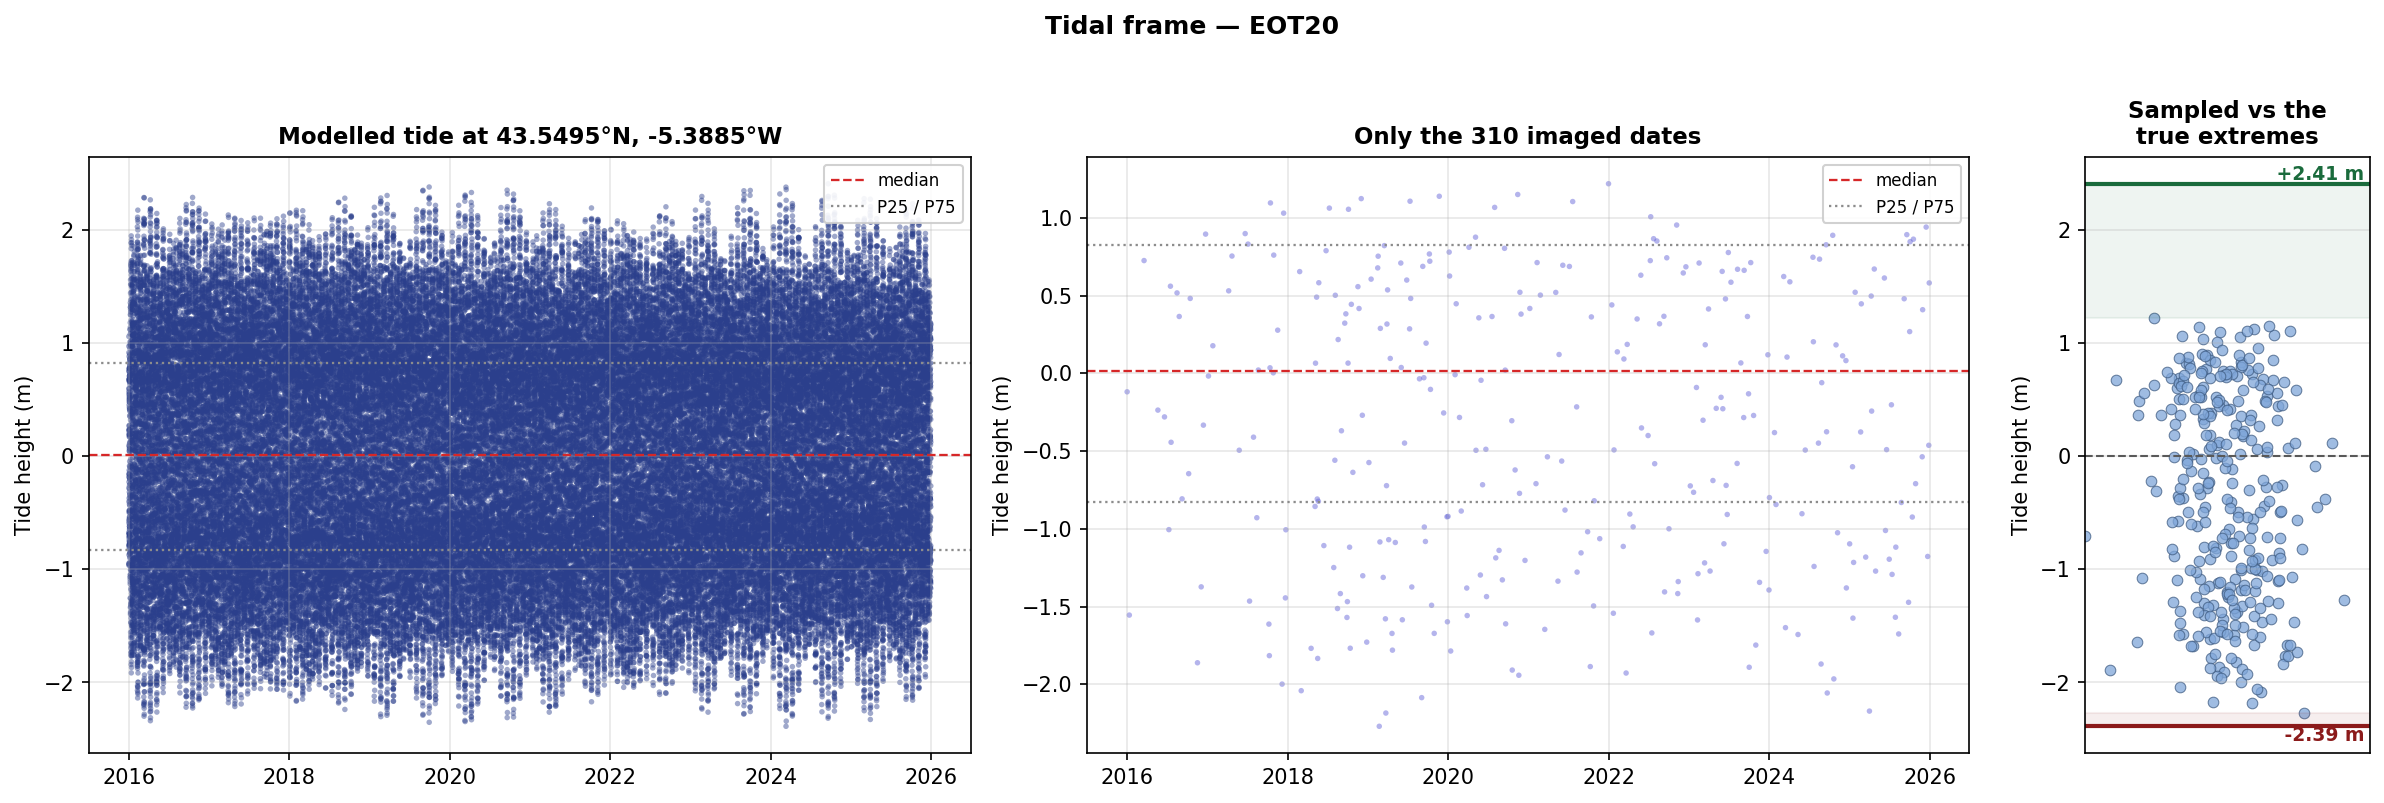

In [25]:
# Three views of the tidal frame over the whole period:
#   left    every modelled tide height — the envelope the estuary experiences
#   centre  only the heights the satellite caught
#   right   those same heights against the true extremes, so the band no
#           image reaches is a distance you can read in metres
sampled_times = pd.to_datetime(sorted(tide_heights))
sampled = np.array([tide_heights[d] for d in sorted(tide_heights)])

viz.plot_tide_record(series_times, series_heights, sampled_times, sampled,
                     model_name=TIDE_MODEL, location=tide_point);

## 7b — MAREA: measuring the tide the model cannot see

Section 6 pinned a term of the error budget: the tide model predicts at an
ocean cell kilometres away, and inside an estuary the tide arrives late and
deformed — minutes of clock error become tens of centimetres of water level
assigned to every scene. MAREA measures that interior tide from the archive
itself:

* every intertidal pixel is a **binary threshold sensor** — wet when the
  water tops its elevation — so its wet/dry sequence records *when* the
  water crossed it;
* the flat is banded by geodesic distance from the mouth, and each band's
  clock lag τ is the one that makes its wet/dry record most probable
  (profiled Bernoulli likelihood: every pixel is granted its best elevation
  and width first, so only the clocks remain as unknowns);
* an exact invariance of that likelihood (the affine theorem) says binary
  data can never recover gain or datum — only **phase** — so those stay
  with the ocean model and only the measurable part is corrected;
* the operator $h(s,t) = h_B(t-	au(s))$ is applied **only** where the lag
  clears a pre-registered detection threshold; elsewhere the model's clock
  is kept, and the product says so.

The identifiability of exactly this fit was gated against a calibrated
digital twin, and adoption against a matched null — see
`research/01_interior_tide_identifiability.ipynb` and
`research/03_operator_and_gauges.ipynb`. One call runs the identical
pipeline every campaign cell runs — nothing below is site-specific:

In [ ]:
# The whole interior-tide product in one call: extract the binary wet/dry
# record, band the flat by geodesic distance from the mouth, fit each band's
# clock, and re-invert every elevation with the corrected clock.
# Writes products_marea/{marea.npz, result.json, figure.png}.
marea_res = pit.marea.reconstruct(cube.cache_path, out_dir="products_marea",
                                  name=aoi.name)
assert marea_res["estado"] == "ok"
print(f"scenes with an exact overpass time: {marea_res['n_escenas']}")
print(f"pixels inverted: {marea_res['n_px_cota']:,} / {marea_res['n_px']:,}")
print(f"interior tide adopted: {marea_res['con_operador']}")

In [ ]:
# The measured clocks. `tau_min` is the fitted lag per band of distance from
# the mouth; `tau_usado_min` is what the product actually applies — bands
# inside the detection threshold keep the model's clock (τ = 0), which is
# the honest verdict there, verified, not assumed.
centres = marea_res["centros_km"]
plt.figure(figsize=(7.5, 4.2))
plt.plot(centres, marea_res["tau_min"], "o-", color="#1a76b3",
         label="fitted lag")
plt.step(centres, marea_res["tau_usado_min"], where="mid", color="crimson",
         lw=2, label=f"applied (detection threshold "
                     f"{pit.marea.TAU_DETECT_MIN:.0f} min)")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("distance from the mouth  s  (km)")
plt.ylabel("cotidal lag  (min)")
plt.title("The interior tide, measured from the imagery alone")
plt.legend(); plt.grid(alpha=0.3);

## 8 · Elevation

Our estimator, **HSR**, uses the physics of mixed pixels. A 10 m pixel on the
waterline is *partially* flooded, so its NDWI is the mixture of its wet and dry
parts, and as the tide rises the wet fraction traces the pixel's internal
hypsometry. Fitting that sigmoid per pixel gives three things at once:

* **μ** — the elevation (the whole curve is used, so no threshold crossing);
* **σ** — the relief *inside* the pixel, a sub-pixel product;
* **σ(μ)** — a Cramér–Rao uncertainty, offered as quality control.

Fitted per **epoch**, not per decade: intertidal morphology migrates, and
fitting ten years at once blurs the transition. Measured here on the same
pixels with only the time window changed, σ is pinned at the widest value the
grid offers for **15.6 %** of pixels over ten years against **10.8 %** over
three, and the median fit residual drops from **0.215 to 0.191** NDWI. The
three-year fit also resolves slightly *more* pixels (33 313 against 31 487),
so the shorter window costs no coverage.

> **Read the uncertainty with caution.** A split-half test (the dates halved
> into two sets with matched tidal coverage, fitted independently) puts the
> typical pixel's repeatability at ~5 cm, but the Cramér–Rao value predicts
> ~3 cm where ~10 cm is observed, and does not separate stable pixels from
> unstable ones within the bulk of the distribution. It is not yet calibrated;
> treat it as indicative. See section 9.


In [26]:
# ── Parameters ───────────────────────────────────────────────────
EPOCH_YEARS     = 3       # morphology is stable enough within ~3 years
SCALE           = 4       # super-resolution factor: 10 m → 2.5 m
MAX_UNCERTAINTY = 0.10    # drop pixels whose σ(μ) exceeds 10 cm
SIGMA_FLOOR     = 0.05    # noise floor of σ, not injected as relief
TIDE_BINS       = "auto"  # from this archive's own tide sampling
MIN_REGION_PX   = 25      # blank isolated specks (25 px at 10 m = 0.25 ha)

epoch_list = pit.epochs(sorted(tide_heights), epoch_years=EPOCH_YEARS)
for e in epoch_list:
    print(f"  epoch {e['label']}: {len(e['dates'])} dates")

latest = epoch_list[-1]
print(f"\nfitting the most recent epoch: {latest['label']}")

# ── HSR fit (local: no cloud job) ─────────────────────────────────
# `tide_bins` averages every observation sharing a tide level before fitting:
# scene noise is independent of tide height while the signal is a function of
# it, so averaging cancels one and keeps the other.
#
# The COUNT is not a free choice. Too few bins quantise the tide axis until a
# pixel's whole transition fits inside one bin and its elevation stops being
# identifiable there; too many average nothing. Measured on the Tagus against
# a real bathymetric survey: 40 bins gave RMSE 0.339 m with 39 % of pixels
# pinned at the bottom of the σ grid, no binning gave 0.289 m, and the optimum
# near 150 bins gave 0.275 m. "auto" derives the count from the tide sampling
# of this archive, which is what sets that balance.
dem = pit.fit_hsr(
    cube, tide_heights,
    dates=latest["dates"],
    scale=SCALE,
    sigma_floor=SIGMA_FLOOR,
    max_uncertainty=MAX_UNCERTAINTY,
    clip_mask=intertidal,
    epoch_label=latest["label"],
    tide_bins=TIDE_BINS,
)

# A per-pixel fit makes per-pixel decisions, so a few isolated pixels far
# from the estuary can pass on their own. Real flats are contiguous.
before = int(np.isfinite(dem.mu).sum())
dem.mu = pit.terrain.drop_small_regions(dem.mu, min_region_px=MIN_REGION_PX)
print(f"\ndespeckled: {before:,} → {int(np.isfinite(dem.mu).sum()):,} px")
dem.summary()

log.record("HSR elevation", kind="apply",
           params={"epoch": latest["label"], "scale": SCALE,
                   "tide_bins": TIDE_BINS,
                   "max_uncertainty": MAX_UNCERTAINTY},
           inputs=[f"{len(latest['dates'])} dates", "tide heights"],
           outputs=["elevation", "sub-pixel relief", "uncertainty"])

  epoch 2016-2016: 17 dates
  epoch 2017-2019: 103 dates
  epoch 2020-2022: 89 dates
  epoch 2023-2025: 101 dates

fitting the most recent epoch: 2023-2025


[hsr] tide_bins='auto' → 28 bins (11.12 cm each)


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:360: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(block, axis=0)


[hsr] filas 32/887 ( 3.6 %)  14:49:02  faltan ~7.9 min


[hsr] filas 64/887 ( 7.2 %)  14:49:23  faltan ~8.2 min


[hsr] filas 96/887 (10.8 %)  14:49:39  faltan ~7.5 min


[hsr] filas 128/887 (14.4 %)  14:49:51  faltan ~6.6 min


[hsr] filas 160/887 (18.0 %)  14:50:04  faltan ~6.0 min


[hsr] filas 192/887 (21.6 %)  14:50:16  faltan ~5.5 min


[hsr] filas 224/887 (25.3 %)  14:50:29  faltan ~5.1 min


[hsr] filas 256/887 (28.9 %)  14:50:39  faltan ~4.7 min


[hsr] filas 288/887 (32.5 %)  14:50:54  faltan ~4.5 min


[hsr] filas 320/887 (36.1 %)  14:51:09  faltan ~4.3 min


[hsr] filas 352/887 (39.7 %)  14:51:22  faltan ~4.0 min


[hsr] filas 384/887 (43.3 %)  14:51:32  faltan ~3.7 min


[hsr] filas 416/887 (46.9 %)  14:51:46  faltan ~3.4 min


[hsr] filas 448/887 (50.5 %)  14:51:58  faltan ~3.2 min


[hsr] filas 480/887 (54.1 %)  14:52:09  faltan ~2.9 min


[hsr] filas 512/887 (57.7 %)  14:52:18  faltan ~2.6 min


[hsr] filas 544/887 (61.3 %)  14:52:31  faltan ~2.4 min


[hsr] filas 576/887 (64.9 %)  14:52:41  faltan ~2.1 min


[hsr] filas 608/887 (68.5 %)  14:52:51  faltan ~1.9 min


[hsr] filas 640/887 (72.2 %)  14:53:03  faltan ~1.7 min


[hsr] filas 672/887 (75.8 %)  14:53:13  faltan ~1.4 min


[hsr] filas 704/887 (79.4 %)  14:53:24  faltan ~1.2 min


[hsr] filas 736/887 (83.0 %)  14:53:34  faltan ~1.0 min


[hsr] filas 768/887 (86.6 %)  14:53:44  faltan ~0.8 min


[hsr] filas 800/887 (90.2 %)  14:53:55  faltan ~0.6 min


[hsr] filas 832/887 (93.8 %)  14:54:03  faltan ~0.4 min


[hsr] filas 864/887 (97.4 %)  14:54:10  faltan ~0.1 min


[hsr] filas 887/887 (100.0 %)  14:54:16  faltan ~0.0 min



despeckled: 25,185 → 24,813 px
[hsr · 2023-2025] 24,813 px
  elevation [-2.07, 0.84] m
  sub-pixel relief σ: median 15 cm | saturated 10%
  uncertainty: median 2.1 cm


Operation(name='HSR elevation', kind='apply', params={'epoch': '2023-2025', 'scale': 4, 'tide_bins': 'auto', 'max_uncertainty': 0.1}, inputs=['101 dates', 'tide heights'], outputs=['elevation', 'sub-pixel relief', 'uncertainty'], before=None, after=None, note='', seconds=0.0)

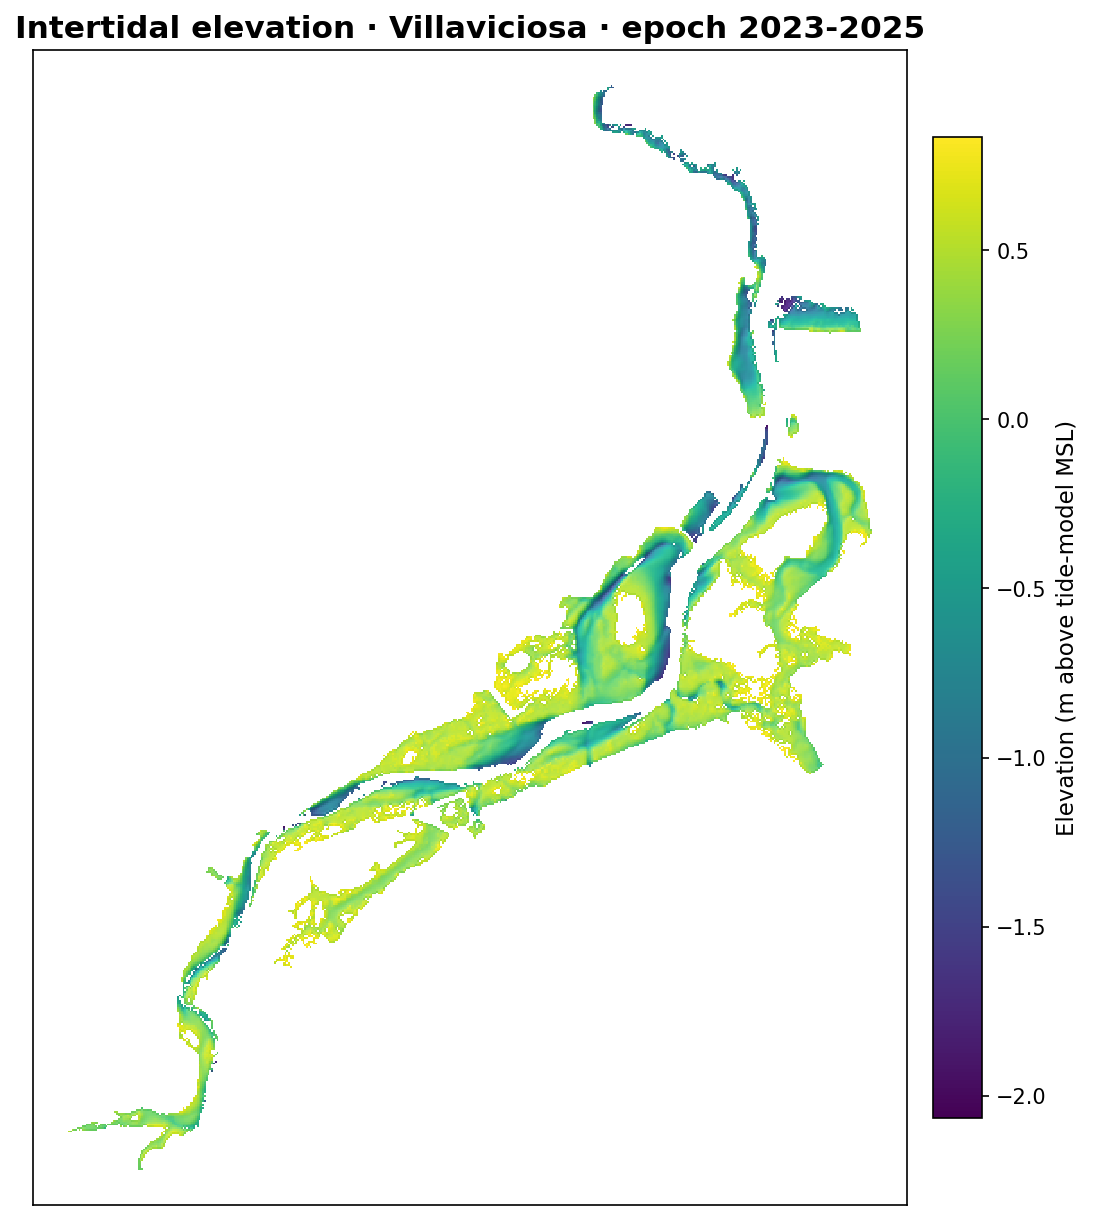

In [27]:
viz.plot_dem(dem.mu, transform, crs, aoi,
             title=f"Intertidal elevation · {aoi.name} · epoch {dem.epoch}");

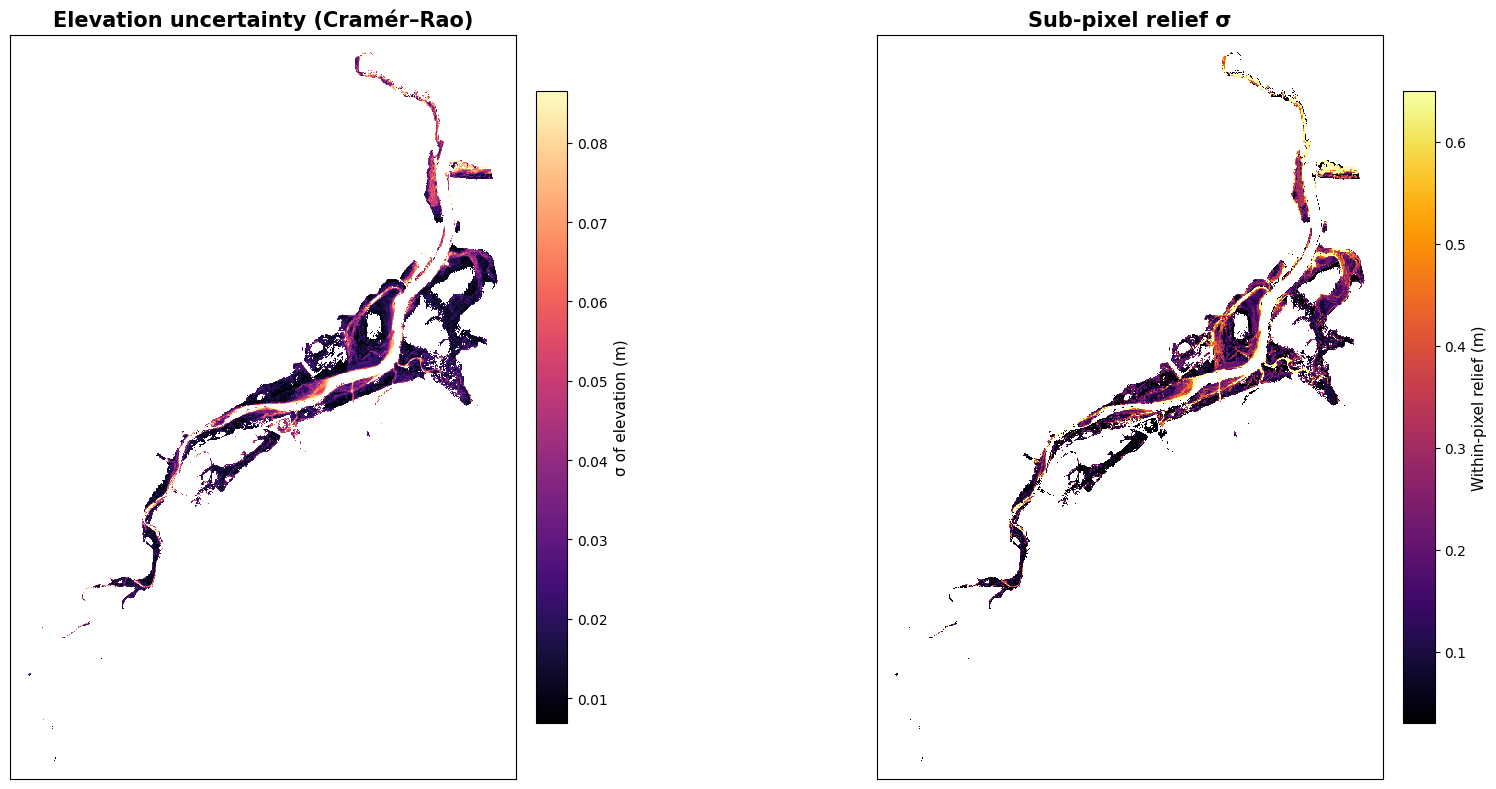

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
viz.plot_uncertainty(dem.sigma_mu, transform, crs, aoi,
                     title="Elevation uncertainty (Cramér–Rao)", ax=axes[0])
viz.plot_subpixel_relief(dem.sigma, transform, crs, aoi,
                         title="Sub-pixel relief σ", ax=axes[1])
fig.tight_layout();

### The published baseline, for comparison

The DEA-style **step** method reads the tide at which the rolling median of
NDWI crosses from dry to wet. It is more selective than HSR — it needs a clean
monotonic transition — and provides no uncertainty, but it is the reference
method of the literature and runs from the same cube.

In [29]:
dem_step = pit.fit_step(
    cube, tide_heights, dates=latest["dates"],
    threshold=NDWI_THRESHOLD, min_obs=5,
    clip_mask=intertidal, epoch_label=latest["label"],
)
dem_step.mu = pit.terrain.drop_small_regions(dem_step.mu,
                                             min_region_px=MIN_REGION_PX)
dem_step.summary()

print(f"\\ncoverage: HSR {int(np.isfinite(dem.mu).sum()):,} px vs "
      f"step {int(np.isfinite(dem_step.mu).sum()):,} px")

[step] filas 32/887  14:58:47


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:1018: RuntimeWarning: All-NaN slice encountered
  z = np.nanmin(wet_tide, axis=0)


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:995: RuntimeWarning: All-NaN slice encountered
  m_ = np.nanmedian(block, axis=0)


[step] filas 64/887  14:59:02


[step] filas 96/887  14:59:12


[step] filas 128/887  14:59:22


[step] filas 160/887  14:59:32


[step] filas 192/887  14:59:42


[step] filas 224/887  14:59:52


[step] filas 256/887  15:00:02


[step] filas 288/887  15:00:19


[step] filas 320/887  15:00:29


[step] filas 352/887  15:00:39


[step] filas 384/887  15:00:50


[step] filas 416/887  15:01:00


[step] filas 448/887  15:01:10


[step] filas 480/887  15:01:20


[step] filas 512/887  15:01:30


[step] filas 544/887  15:01:48


[step] filas 576/887  15:01:58


[step] filas 608/887  15:02:09


[step] filas 640/887  15:02:19


[step] filas 672/887  15:02:29


[step] filas 704/887  15:02:39


[step] filas 736/887  15:02:49


[step] filas 768/887  15:02:59


[step] filas 800/887  15:03:13


[step] filas 832/887  15:03:22


[step] filas 864/887  15:03:31


[step] filas 887/887  15:03:39


[step · 2023-2025] 18,332 px
  elevation [-1.96, 0.64] m


  sub-pixel relief σ: median nan cm | saturated 0%
  uncertainty: median nan cm
\ncoverage: HSR 24,813 px vs step 18,332 px


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:737: RuntimeWarning: All-NaN slice encountered
  f"{np.nanmedian(self.sigma[v]) * 100:.0f} cm | "
C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:740: RuntimeWarning: All-NaN slice encountered
  f"{np.nanmedian(self.sigma_mu[v]) * 100:.1f} cm")


## 9 · Validation against airborne LiDAR

The IGN 5 m LiDAR survey is an independent measurement of the same surface.
Two cautions before reading the numbers, and the second is the important one.

Our elevations are referenced to the tide-model datum and LiDAR to an
orthometric one, so their offset appears as a **bias** that says nothing about
method skill. RMSE and MAE are therefore computed after removing it.

**This reference is not adequate for the intertidal zone.** The INSPIRE WCS
serves the product as `int16`, i.e. rounded to the metre — across our whole
intertidal range there are seven distinct values, and that rounding alone
contributes 1/√12 = 0.29 m of RMSE. Worse, the survey flies at whatever tide
state it finds, so over a flooded flat it returns the water surface rather
than the bed. The next cell quantifies exactly that, and any ranking of
methods built on these numbers should be treated as uninformative until a
float-precision reference (MDT05 from the download centre, or the field
transect) is available.

In [30]:
lidar = None
# The report cell at the end always passes validation=rows, so this
# must exist even where there is no LiDAR to compare against — which
# is every cell of the north-coast campaign. Defining it only inside
# the else branch made all 116 cells fail with NameError before a
# single product was written.
rows = []
if MDT_PATH is None:
    print("no LiDAR reference configured for this run — section skipped")
else:
    pit.download_mdt_ign({**aoi.bbox, "crs": "EPSG:4326"}, MDT_PATH)
    lidar = pit.reproject_to_grid(MDT_PATH, transform, crs,
                                  reference_map.shape)
    print(f"LiDAR reprojected onto the analysis grid: "
          f"{np.isfinite(lidar).mean() * 100:.0f}% coverage")

    # Before comparing anything TO it, look at what it is. These two lines
    # are the whole argument of this section.
    inside = lidar[intertidal & np.isfinite(lidar)]
    values = np.unique(inside)
    top = float(np.bincount(np.searchsorted(values, inside)).max()) / inside.size
    print(f"\nthe reference itself, inside our intertidal mask:")
    print(f"  {len(values)} distinct values in {inside.size:,} pixels")
    print(f"  the commonest one holds {100 * top:.0f}% of them "
          f"(= {values[np.bincount(np.searchsorted(values, inside)).argmax()]:+.2f} m)")
    print(f"  int16 rounding alone contributes 1/sqrt(12) = 0.29 m of RMSE")

    # Computed so the failure is visible, NOT as a ranking of the methods.
    rows = pit.compare_dems({"HSR": dem.mu, "step (DEA)": dem_step.mu}, lidar)
    print("\nscored against it anyway — these numbers rank the reference's"
          "\nfailure, not the methods:")
    display(pd.DataFrame(rows))


LiDAR reprojected onto the analysis grid: 100% coverage



the reference itself, inside our intertidal mask:
  3026 distinct values in 30,446 pixels
  the commonest one holds 76% of them (= +2.00 m)
  int16 rounding alone contributes 1/sqrt(12) = 0.29 m of RMSE

scored against it anyway — these numbers rank the reference's
failure, not the methods:


,method,n,bias_m,rmse_m,mae_m,pearson_r,spearman
0,HSR,24813,-1.640,0.614,0.428,0.316,0.222
1,step (DEA),18332,-1.852,0.694,0.512,0.338,0.265


### The check that needs no elevation model at all

Water frequency must be **negatively** correlated with elevation: higher
ground floods less often. That is close to model-free — it only counts how
often each pixel was wet — which makes it the right arbiter when the
reference DEM itself is in doubt.

Run it on every elevation raster in play, including the LiDAR. Whichever
raster fails this test is the one to distrust.

In [31]:
# Run the arbiter on every elevation raster in play. Whichever fails is the
# one to distrust — and it is not the satellite products.
for label, raster in [("HSR", dem.mu), ("step (DEA)", dem_step.mu),
                      ("IGN LiDAR", lidar)]:
    if raster is None:
        continue
    r = pit.validation.wf_vs_elevation(water_freq, raster, mask=intertidal)
    print(f"  {label:12s} Spearman {r['spearman']:+.3f}  "
          f"(n = {r['n']:,})")
print("\nA real elevation surface must correlate NEGATIVELY and strongly.")


  HSR          Spearman -0.848  (n = 24,813)
  step (DEA)   Spearman -0.963  (n = 18,332)
  IGN LiDAR    Spearman -0.260  (n = 30,446)

A real elevation surface must correlate NEGATIVELY and strongly.


### Field survey — RTK GNSS

Because the LiDAR cannot arbitrate, we measured the flat ourselves: **361
fixed-solution GNSS points at 1.3 cm**, occupied at the lowest spring tide of
the month. This is the only reference in the study that is unambiguously the
*bed* rather than whatever the water was doing.

Two things to read carefully. Points that fall outside the mapped zone are
reported rather than dropped quietly — most of them were never once observed
wet in nine years of imagery, which is an observational limit of the archive
and not a failure of the fit. And both estimators are scored on the **same**
pixels, since they do not resolve the same set and comparing them on different
ones proves nothing.


In [32]:
from pyproj import Transformer

if FIELD_CSV is None:
    print("no field survey configured for this run — section skipped")
else:
    fx = pd.read_csv(FIELD_CSV)
    fx = fx[fx["Solution status"] == "FIX"]

    # Several GNSS points land in the same 10 m pixel; average them, so one
    # densely walked pixel does not outvote the rest.
    tf = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    x, y = tf.transform(fx["Longitude"].values, fx["Latitude"].values)
    col = ((x - transform.c) / transform.a).astype(int)
    row = ((y - transform.f) / transform.e).astype(int)
    flat, inv = np.unique(row * cube.shape[1] + col, return_inverse=True)
    counts = np.bincount(inv)
    surveyed = np.bincount(inv, weights=fx["Ellipsoidal height"].values) / counts
    rr, cc = flat // cube.shape[1], flat % cube.shape[1]

    # Why points are lost, stated rather than implied.
    wf_here = water_freq[rr, cc]
    never_wet = int(np.nansum(wf_here == 0))
    print(f"{len(fx)} FIX points → {len(flat)} distinct pixels")
    print(f"  {never_wet} of those were never observed wet in the archive "
          f"— unmappable by any method, not a fit failure")

    both = np.isfinite(dem.mu[rr, cc]) & np.isfinite(dem_step.mu[rr, cc])
    print(f"  {int(both.sum())} pixels resolved by BOTH estimators "
          f"— the only fair comparison")

    print(f"\n{'method':14s} {'RMSE (m)':>9s} {'r':>7s} {'slope':>7s}")
    print("-" * 42)
    for label, raster in [("HSR", dem.mu), ("step (DEA)", dem_step.mu)]:
        v = raster[rr, cc][both]
        g = surveyed[both]
        d = g - v
        d = d - np.median(d)          # datum, not skill: tide MSL vs ellipsoid
        print(f"{label:14s} {np.sqrt(np.mean(d ** 2)):9.3f} "
              f"{np.corrcoef(g, v)[0, 1]:7.3f} "
              f"{np.polyfit(g, v, 1)[0]:7.3f}")
    print("\nThe slope is the number to watch: below 1 the map compresses "
          "relief.\nSection 9b explains why, and it is not the estimator.")


361 FIX points → 248 distinct pixels
  35 of those were never observed wet in the archive — unmappable by any method, not a fit failure
  112 pixels resolved by BOTH estimators — the only fair comparison

method          RMSE (m)       r   slope
------------------------------------------
HSR                0.165   0.886   0.665
step (DEA)         0.136   0.918   0.907

The slope is the number to watch: below 1 the map compresses relief.
Section 9b explains why, and it is not the estimator.


## 10 · From topography to habitat

Elevation is a means, not an end. What organises intertidal life is the
**hydroperiod**: the fraction of time a spot is submerged. Computing it from
the continuous tide series (not from the satellite dates, which are unevenly
sampled) turns our DEM into an ecological map.

In [33]:
hydro = pit.hydroperiod.hydroperiod(dem.mu, series_heights)
zones, zone_labels = pit.hydroperiod.zonation(dem.mu, series_heights)
zone_table = pit.hydroperiod.zone_areas(zones, zone_labels, transform)

print(f"hydroperiod: {np.nanmin(hydro):.0%} – {np.nanmax(hydro):.0%} "
      f"of the time submerged (median {np.nanmedian(hydro):.0%})\n")
pd.DataFrame(zone_table)

hydroperiod: 25% – 100% of the time submerged (median 44%)



,zone,code,pixels,area_km2,percent
0,subtidal,1,403,0.040,1.6
1,lower intertidal,2,7158,0.716,28.8
2,mid intertidal,3,17252,1.725,69.5
3,upper intertidal,4,0,0.000,0.0
4,supratidal,5,0,0.000,0.0


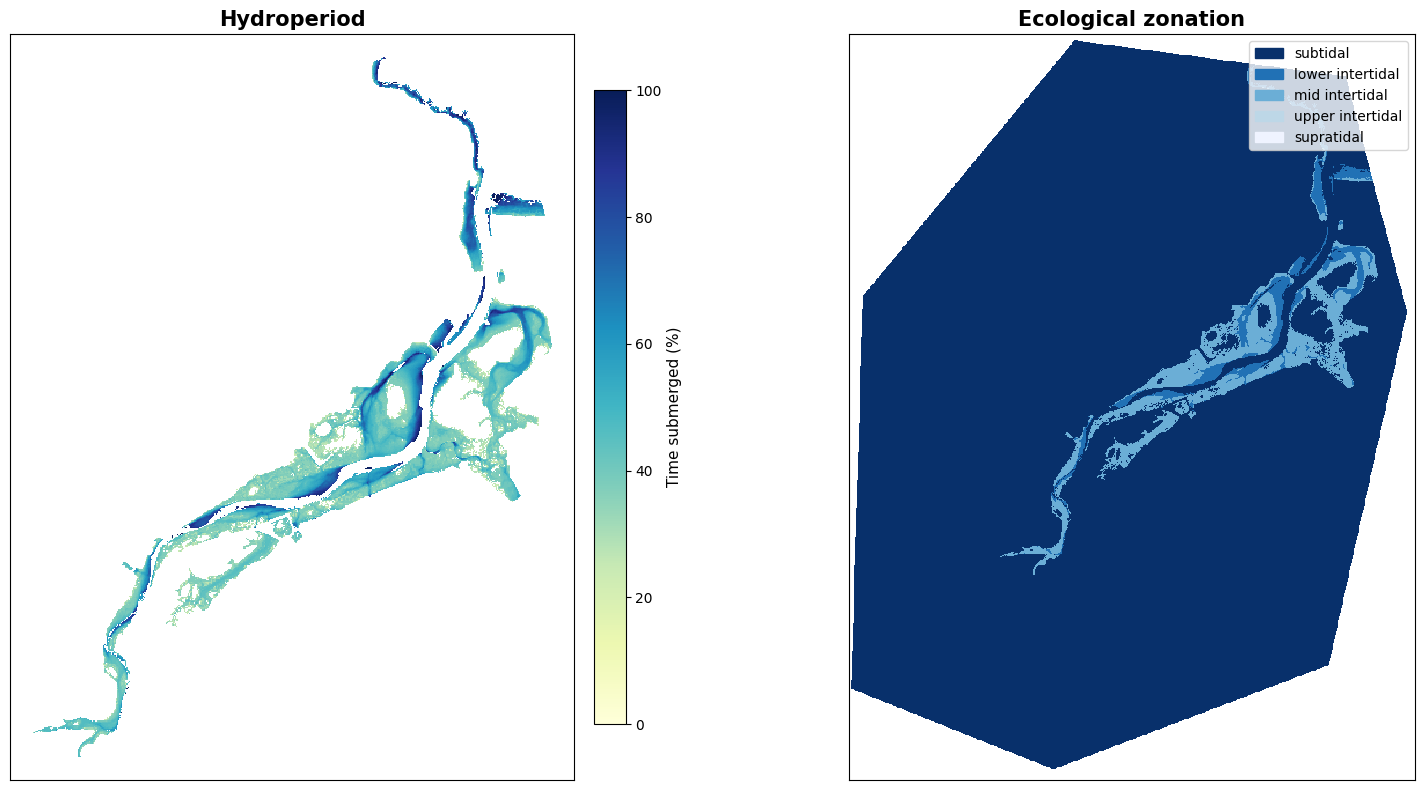

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
viz.plot_map(hydro * 100, transform, crs, aoi, cmap="YlGnBu",
             vmin=0, vmax=100, robust=False,
             title="Hydroperiod", cbar_label="Time submerged (%)", ax=axes[0])
viz.plot_map(zones.astype(float), transform, crs, aoi,
             classes={c: (zone_labels[c], col) for c, col in
                      zip(sorted(zone_labels)[1:],
                          ["#08306b", "#2171b5", "#6baed6", "#bdd7e7", "#eff3ff"])},
             title="Ecological zonation", ax=axes[1])
fig.tight_layout();

### Morphological signature

The hypsometric curve — how much area lies below each elevation — is the
compact fingerprint of the estuary's shape, and the natural quantity to
compare between epochs or between sites.

[hypsometry] Villaviciosa
  intertidal area   2.48 km²
  elevation range   -2.07 … +0.84 m (median +0.25)
  hypsometric integral 0.751 → convex — area concentrated high (accretional signature)


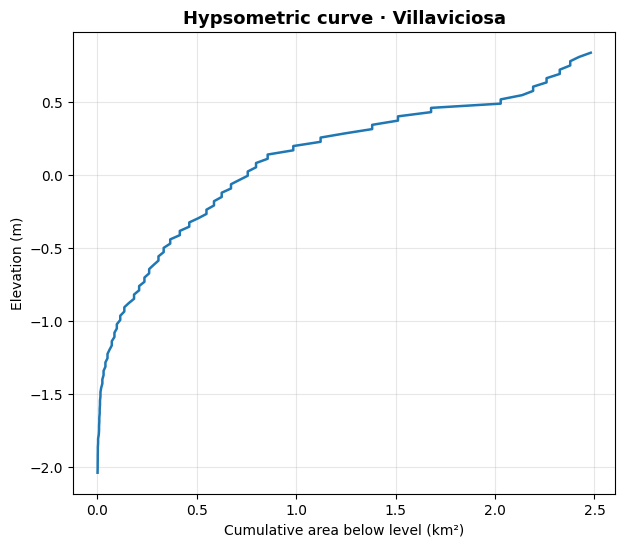

In [35]:
curve = pit.hypsometry.hypsometric_curve(dem.mu, transform)
summary = pit.hypsometry.describe(curve, aoi.name)

pit.hypsometry.plot_curves({aoi.name: curve},
                           title=f"Hypsometric curve · {aoi.name}");

### Change between epochs

With two epochs fitted, the difference is a change map. The rule that keeps it
honest: **never subtract two DEMs without their uncertainties**. Only changes
larger than the propagated uncertainty are reported.

comparing 2020-2022 → 2023-2025


[hsr] filas 32/887 ( 3.6 %)  15:04:22  faltan ~18.5 min


[hsr] filas 64/887 ( 7.2 %)  15:05:03  faltan ~17.5 min


[hsr] filas 96/887 (10.8 %)  15:05:43  faltan ~16.8 min


[hsr] filas 128/887 (14.4 %)  15:06:22  faltan ~15.9 min


[hsr] filas 160/887 (18.0 %)  15:06:59  faltan ~15.0 min


[hsr] filas 192/887 (21.6 %)  15:07:35  faltan ~14.1 min


[hsr] filas 224/887 (25.3 %)  15:08:11  faltan ~13.3 min


[hsr] filas 256/887 (28.9 %)  15:08:46  faltan ~12.6 min


[hsr] filas 288/887 (32.5 %)  15:09:25  faltan ~11.9 min


[hsr] filas 320/887 (36.1 %)  15:10:01  faltan ~11.2 min


[hsr] filas 352/887 (39.7 %)  15:10:37  faltan ~10.6 min


[hsr] filas 384/887 (43.3 %)  15:11:14  faltan ~9.9 min


[hsr] filas 416/887 (46.9 %)  15:11:50  faltan ~9.2 min


[hsr] filas 448/887 (50.5 %)  15:12:26  faltan ~8.6 min


[hsr] filas 480/887 (54.1 %)  15:13:04  faltan ~8.0 min


[hsr] filas 512/887 (57.7 %)  15:13:40  faltan ~7.3 min


[hsr] filas 544/887 (61.3 %)  15:14:18  faltan ~6.7 min


[hsr] filas 576/887 (64.9 %)  15:14:54  faltan ~6.1 min


[hsr] filas 608/887 (68.5 %)  15:15:30  faltan ~5.4 min


[hsr] filas 640/887 (72.2 %)  15:16:06  faltan ~4.8 min


[hsr] filas 672/887 (75.8 %)  15:16:43  faltan ~4.2 min


[hsr] filas 704/887 (79.4 %)  15:17:20  faltan ~3.5 min


[hsr] filas 736/887 (83.0 %)  15:17:56  faltan ~2.9 min


[hsr] filas 768/887 (86.6 %)  15:18:32  faltan ~2.3 min


[hsr] filas 800/887 (90.2 %)  15:19:08  faltan ~1.7 min


[hsr] filas 832/887 (93.8 %)  15:19:43  faltan ~1.1 min


[hsr] filas 864/887 (97.4 %)  15:20:18  faltan ~0.4 min


[hsr] filas 887/887 (100.0 %)  15:20:44  faltan ~0.0 min


[morphodynamics] 2020-2022 → 2023-2025
  16,470 of 22,741 pixels changed significantly (72%) at 1.96σ
  accretion +100,310 m³ over 0.41 km²
  erosion   -247,580 m³ over 1.24 km²
  net       -147,270 m³ → eroding


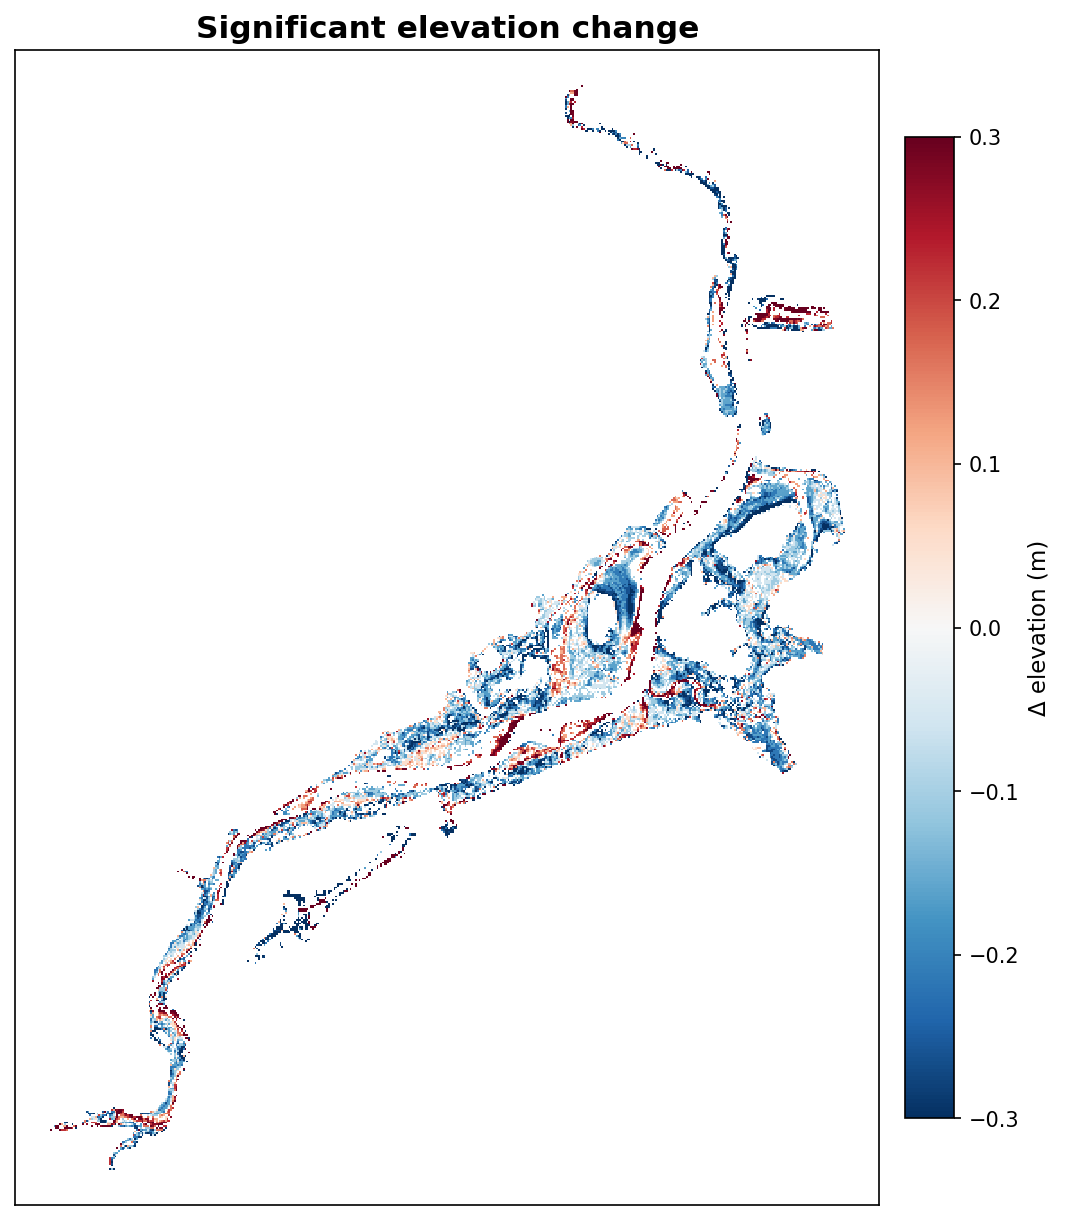

In [36]:
if len(epoch_list) >= 2:
    previous = epoch_list[-2]
    print(f"comparing {previous['label']} → {latest['label']}")

    dem_prev = pit.fit_hsr(cube, tide_heights, dates=previous["dates"],
                           scale=SCALE, max_uncertainty=MAX_UNCERTAINTY,
                           clip_mask=intertidal, epoch_label=previous["label"],
                           superresolve=False)

    change = pit.morphodynamics.dem_difference(
        dem_prev.mu, dem.mu, dem_prev.sigma_mu, dem.sigma_mu, confidence=1.96)
    budget = pit.morphodynamics.summarize(change, transform,
                                          f"{previous['label']} → {latest['label']}")

    viz.plot_map(np.where(change["significant"], change["change"], np.nan),
                 transform, crs, aoi, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
                 robust=False, title="Significant elevation change",
                 cbar_label="Δ elevation (m)")
else:
    print("only one epoch available — skip the change analysis")

## 11 · Provenance and outputs

The process graph of everything above: which operations ran, in which order,
with which parameters. This is the figure that makes the study auditable by
somebody who did not run it.

In [37]:
explain.draw_graph(log)

<pyintertidal diagram: process graph · Villaviciosa 2016–2025 — display it in a notebook or call .save(path)>

In [38]:
log.table()

,step,operation,kind,inputs,outputs,note,params,seconds
0,1,acquire datacube,acquire,,cube,"1379 scenes, cached once",water=ndwi · resolution_m=10,0.0
1,2,reference map + cloud stats,reduce,cube,"reference map, cloud %",,stable_threshold=0.95 · buffer_px=10,0.0
2,3,filter dates,filter,,310 dates,+7% vs a global filter,cloud_threshold=0.1,0.0
3,4,water frequency,reduce,310 dates,water frequency,,min_obs=16 · threshold=0.0,0.0
4,5,intertidal mask,mask,,intertidal mask,3.04 km²,wf_low=0.05 · wf_high=0.95,0.0
5,6,tide heights,apply,,310 tide heights,,"model=EOT20 · point=43.549,-5.389 · ocean_cell...",0.0
6,7,HSR elevation,apply,"101 dates, tide heights","elevation, sub-pixel relief, uncertainty",,epoch=2023-2025 · scale=4 · tide_bins=auto · m...,0.0


Finally, write the products, package them with STAC metadata that carries the parameters, and build a single self-contained HTML report.

In [39]:
import os

# Rasters (10 m grid, clipped to the polygon) + the super-resolved DEM
dem.save(OUT_DIR)
pit.write_geotiff(f"{OUT_DIR}/water_frequency.tif", water_freq,
                  transform, crs, "float32", np.nan)
pit.write_geotiff(f"{OUT_DIR}/intertidal_mask.tif",
                  intertidal.astype("uint8"), transform, crs, "uint8", None)
pit.write_geotiff(f"{OUT_DIR}/hydroperiod.tif", hydro,
                  transform, crs, "float32", np.nan)

# Provenance travels with the data
item = pit.export.stac_item(
    f"{OUT_DIR}/hsr_elevation.tif", aoi=aoi,
    datetime_utc=f"{latest['label'][-4:]}-07-01",
    properties={"pyintertidal:method": "hsr",
                "pyintertidal:epoch": latest["label"],
                "pyintertidal:ndwi_threshold": NDWI_THRESHOLD,
                "pyintertidal:cloud_threshold": CLOUD_THRESHOLD,
                "pyintertidal:wf_window": [round(WF_LOW, 3), round(WF_HIGH, 3)],
                "pyintertidal:min_obs": MIN_OBS,
                "pyintertidal:tide_model": TIDE_MODEL,
                "pyintertidal:ocean_cell_km": round(ocean["distance_km"], 1)},
    assets={"uncertainty": f"{OUT_DIR}/hsr_uncertainty.tif",
            "subpixel_relief": f"{OUT_DIR}/hsr_sigma.tif"})
pit.export.write_stac([item], OUT_DIR,
                      description=f"Intertidal products · {aoi.name}")

# ── The cube is disposable; the products are not ────────────────────────
# A regional campaign of ~80 cells at ~1 GB each does not fit on this disk,
# and it does not need to: once the products exist the cube has served its
# purpose. Verify FIRST — every file opened and non-empty — because deleting
# a gigabyte on the strength of a filename that happens to exist is how a
# night's downloading disappears.
if EVICT_CUBE:
    import rasterio
    required = ["hsr_elevation.tif", "water_frequency.tif",
                "intertidal_mask.tif"]
    for name in required:
        path = f"{OUT_DIR}/{name}"
        with rasterio.open(path) as src:          # raises if unreadable
            if not np.isfinite(src.read(1)).any():
                raise RuntimeError(f"{path} opened but holds no data — "
                                   f"refusing to delete {CACHE}")
    size_gb = os.path.getsize(CACHE) / 1e9
    os.remove(CACHE)
    print(f"cube evicted: {CACHE} ({size_gb:.2f} GB) — "
          f"{len(required)} products verified first")


[export] STAC collection with 1 items → products_villaviciosa\collection.json


In [40]:
report_path = pit.report.site_report(
    f"{OUT_DIR}/report_villaviciosa.html",
    aoi, cube=cube,
    params={"period": f"{TIME_EXTENT[0]} → {TIME_EXTENT[1]}",
            "water detector": WATER, "NDWI threshold": NDWI_THRESHOLD,
            "cloud threshold": CLOUD_THRESHOLD, "min observations": MIN_OBS,
            "intertidal window": f"[{WF_LOW:.2f}, {WF_HIGH:.2f}]",
            "epoch": latest["label"], "tide model": TIDE_MODEL},
    coverage=metrics, verdict=verdict,
    validation=rows, zones=zone_table, oplog=log,
    notes="Satellite-derived intertidal topography, produced with pyintertidal.")

print("report written to", report_path)

report written to products_villaviciosa/report_villaviciosa.html


## Notes

* **Scaling out.** This notebook *is* the production cell. `campaign_north_coast.ipynb`
  tiles the coast, replaces the parameters cell at the top, and executes this
  file once per cell with `nbclient`; each executed copy is kept as the
  provenance record of that cell. Set `EVICT_CUBE=True` there and the cube is
  deleted once its products are verified, so ~80 cells cost a few GB of disk
  instead of a hundred. `pyintertidal.mosaic` merges the results and measures
  the seams.
* **What is validated, and what is not.** The elevations here are checked
  against an RTK GNSS field survey, which is the only reference in this study
  that measures the bed rather than the water. The IGN LiDAR is shown in
  section 9 to demonstrate *why* it cannot arbitrate — seven distinct values
  across the flat, 83 % of them the water surface — not to rank the methods.
  Any earlier figure of ours quoting an RMSE "against IGN LiDAR" is withdrawn.
* **The limiting error is the tide, not the estimator.** HSR and the published
  step method tie against the field survey, and both compress relief in the
  same way and by the same amount. See `pyintertidal.tidecheck` for what an
  estuary does to the tide and, more usefully, for which parts of it a
  satellite can and cannot recover.
* **Reproducibility.** Every parameter in this notebook is a named variable,
  and the same values are stored in the STAC item and the HTML report, so a
  result found later can always be traced back to the run that made it.
